# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/y/Desktop/446/lab3/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1


    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [11]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 512)               287744    
                                                                 
 dense_8 (Dense)             (None, 256)               131328    
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dense_10 (Dense)            (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [12]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    callbacks=teacher_callbacks
)


Epoch 1/40
184/184 [==============================] - 1s 3ms/step - loss: 0.3971 - accuracy: 0.8298 - val_loss: 0.4701 - val_accuracy: 0.8321
Epoch 2/40
184/184 [==============================] - 1s 3ms/step - loss: 0.1564 - accuracy: 0.9362 - val_loss: 0.2064 - val_accuracy: 0.9286
Epoch 3/40
184/184 [==============================] - 1s 3ms/step - loss: 0.1122 - accuracy: 0.9548 - val_loss: 0.2738 - val_accuracy: 0.9075
Epoch 4/40
184/184 [==============================] - 1s 3ms/step - loss: 0.1093 - accuracy: 0.9553 - val_loss: 0.1306 - val_accuracy: 0.9483
Epoch 5/40
184/184 [==============================] - 1s 3ms/step - loss: 0.0919 - accuracy: 0.9640 - val_loss: 0.1217 - val_accuracy: 0.9490
Epoch 6/40
184/184 [==============================] - 1s 3ms/step - loss: 0.0963 - accuracy: 0.9624 - val_loss: 0.1289 - val_accuracy: 0.9456
Epoch 7/40
184/184 [==============================] - 1s 3ms/step - loss: 0.0675 - accuracy: 0.9747 - val_loss: 0.1182 - val_accuracy: 0.9558
Epoch 

### Teacher Training Curves


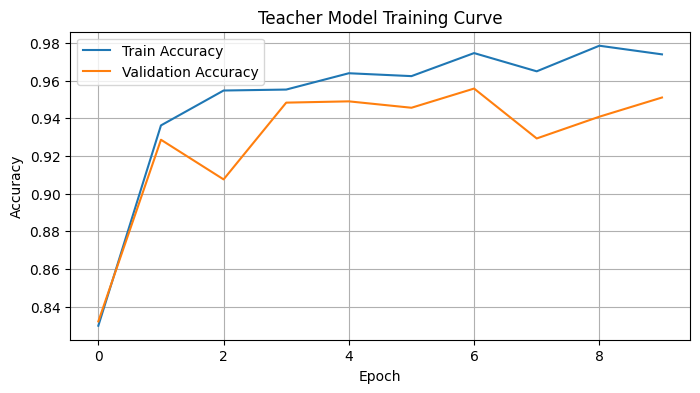

In [13]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [ ]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    #<--- Enter your code here --->#
)


## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [14]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 1ms/step - loss: 0.7791 - accuracy: 0.7216 - val_loss: 0.3484 - val_accuracy: 0.8939
Epoch 2/20
92/92 [==============================] - 0s 845us/step - loss: 0.2787 - accuracy: 0.9043 - val_loss: 0.2155 - val_accuracy: 0.9225
Epoch 3/20
92/92 [==============================] - 0s 814us/step - loss: 0.1825 - accuracy: 0.9359 - val_loss: 0.1858 - val_accuracy: 0.9259
Epoch 4/20
92/92 [==============================] - 0s 1ms/step - loss: 0.1319 - accuracy: 0.9544 - val_loss: 0.1586 - val_accuracy: 0.9334
Epoch 5/20
92/92 [==============================] - 0s 880us/step - loss: 0.1081 - accuracy: 0.9648 - val_loss: 0.1807 - val_accuracy: 0.9259
Epoch 6/20
92/92 [==============================] - 0s 838us/step - loss: 0.0866 - accuracy: 0.9706 - val_loss: 0.1775 - val_accuracy: 0.9313
Epoch 7/20
92/92 [==============================] - 0s 868us/step - loss: 0.0803 - accuracy: 0.9740 - val_loss: 0.1661 - val_accuracy: 0.9313


## 9. Evaluate the Baseline Student Model


In [40]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )

            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [16]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/40
184/184 [==============================] - 1s 2ms/step - accuracy: 0.7789 - student_loss: 0.5974 - distillation_loss: 0.0017 - val_accuracy: 0.9001 - val_student_loss: 0.0442
Epoch 2/40
184/184 [==============================] - 0s 1ms/step - accuracy: 0.9254 - student_loss: 0.2072 - distillation_loss: 4.9581e-04 - val_accuracy: 0.9123 - val_student_loss: 0.0033
Epoch 3/40
184/184 [==============================] - 0s 1ms/step - accuracy: 0.9524 - student_loss: 0.1371 - distillation_loss: 2.7188e-04 - val_accuracy: 0.9069 - val_student_loss: 0.0142
Epoch 4/40
184/184 [==============================] - 0s 1ms/step - accuracy: 0.9589 - student_loss: 0.1075 - distillation_loss: 1.9556e-04 - val_accuracy: 0.9327 - val_student_loss: 0.0081
Epoch 5/40
184/184 [==============================] - 0s 1ms/step - accuracy: 0.9660 - student_loss: 0.0907 - distillation_loss: 1.4307e-04 - val_accuracy: 0.9293 - val_student_loss: 0.0014
Epoch 6/40
184/184 [==============================] - 

## 11. Train the Distilled Student


In [17]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 2ms/step - accuracy: 0.7747 - student_loss: 0.6287 - distillation_loss: 0.0017 - val_accuracy: 0.8987 - val_student_loss: 0.1326
Epoch 2/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9150 - student_loss: 0.2395 - distillation_loss: 5.9347e-04 - val_accuracy: 0.8987 - val_student_loss: 0.0247
Epoch 3/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9446 - student_loss: 0.1569 - distillation_loss: 3.2715e-04 - val_accuracy: 0.9205 - val_student_loss: 0.0122
Epoch 4/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9539 - student_loss: 0.1265 - distillation_loss: 2.4288e-04 - val_accuracy: 0.9307 - val_student_loss: 0.0100
Epoch 5/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.9648 - student_loss: 0.1016 - distillation_loss: 1.7139e-04 - val_accuracy: 0.9307 - val_student_loss: 0.0028
Epoch 6/20
92/92 [==============================] - 0s 1ms/step 

### Distillation Training Curves


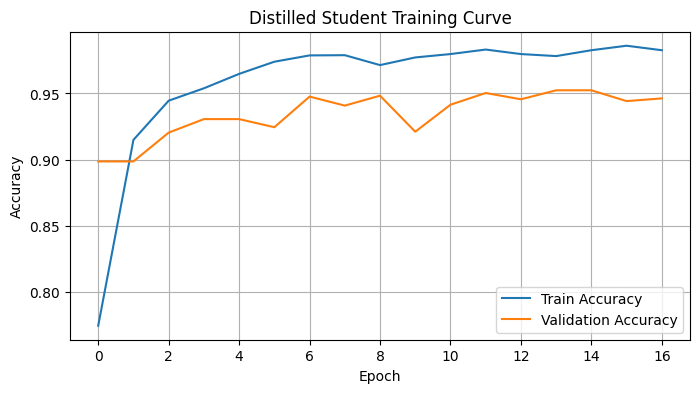

In [18]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9287

                    precision    recall  f1-score   support

           WALKING     0.9091    0.9879    0.9469       496
  WALKING_UPSTAIRS     0.9089    0.9108    0.9099       471
WALKING_DOWNSTAIRS     0.9842    0.8905    0.9350       420
           SITTING     0.9045    0.9063    0.9054       491
          STANDING     0.8814    0.9079    0.8944       532
            LAYING     1.0000    0.9609    0.9801       537

          accuracy                         0.9287      2947
         macro avg     0.9313    0.9274    0.9286      2947
      weighted avg     0.9306    0.9287    0.9289      2947



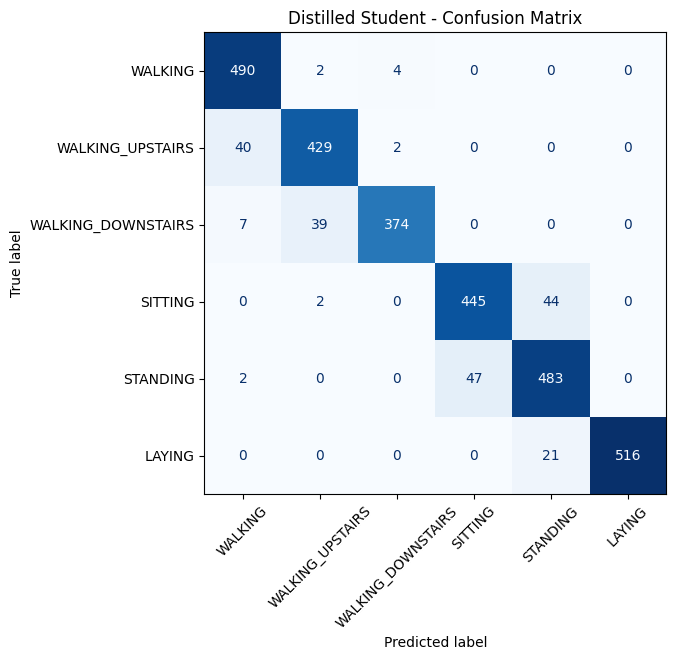

In [19]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [21]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
            
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [31]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]


## 15. Convert the Distilled Student to TensorFlow Lite


In [26]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(
    student_for_pruning, 
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    #<--- Enter your code here --->#
    X_train,
    y_train,
    validation_split = 0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 1s 2ms/step - loss: 0.0354 - accuracy: 0.9884 - val_loss: 0.1439 - val_accuracy: 0.9477
Epoch 2/10
92/92 [==============================] - 0s 975us/step - loss: 0.0424 - accuracy: 0.9876 - val_loss: 0.1092 - val_accuracy: 0.9531
Epoch 3/10
92/92 [==============================] - 0s 966us/step - loss: 0.0653 - accuracy: 0.9825 - val_loss: 0.1147 - val_accuracy: 0.9511
Epoch 4/10
92/92 [==============================] - 0s 944us/step - loss: 0.1073 - accuracy: 0.9708 - val_loss: 0.1225 - val_accuracy: 0.9585
Epoch 5/10
92/92 [==============================] - 0s 980us/step - loss: 0.2274 - accuracy: 0.9262 - val_loss: 0.1776 - val_accuracy: 0.9517
Epoch 6/10
92/92 [==============================] - 0s 938us/step - loss: 0.9331 - accuracy: 0.7426 - val_loss: 0.7354 - val_accuracy: 0.7519
Epoch 7/10
92/92 [==============================] - 0s 1ms/step - loss: 1.6003 - accuracy: 0.5982 - val_loss: 1.8289 - val_accuracy: 0.4697


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [28]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi5zsg0gb/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi5zsg0gb/assets
2026-04-20 11:11:17.377347: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:11:17.377360: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:11:17.377497: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi5zsg0gb
2026-04-20 11:11:17.378933: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:11:17.378938: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi5zsg0gb
2026-04-20 11:11:17.382532: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:11:17.409600: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpll7g9_0a/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpll7g9_0a/assets


Pruned distilled model with mask accuracy: 0.9386
Pruned distilled model with mask size (KB): 304.31
Stripped sparse distilled model accuracy: 0.9386
Stripped sparse distilled model size (KB): 80.96


2026-04-20 11:11:17.701415: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:11:17.701432: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:11:17.701519: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpll7g9_0a
2026-04-20 11:11:17.701824: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:11:17.701828: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpll7g9_0a
2026-04-20 11:11:17.702525: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:11:17.710081: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpll7g9_0a
2026-04-

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [32]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp7ke2w6ml/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp7ke2w6ml/assets


Stripped Sparse + INT8 Accuracy: 0.9372
Stripped Sparse + INT8 Size (KB): 42.46


/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 11:14:52.827154: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:14:52.827165: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:14:52.827266: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp7ke2w6ml
2026-04-20 11:14:52.827585: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:14:52.827589: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp7ke2w6ml
2026-04-20 11:14:52.828327: I tensorflow/cc/saved_model/loader.cc:233] Restor

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [33]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppkgc8d88/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppkgc8d88/assets


Stripped Sparse + INT8 Accuracy: 0.9372
Stripped Sparse + INT8 Size (KB): 42.46


/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 11:14:56.908908: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:14:56.908921: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:14:56.909017: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppkgc8d88
2026-04-20 11:14:56.909348: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:14:56.909352: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppkgc8d88
2026-04-20 11:14:56.910065: I tensorflow/cc/saved_model/loader.cc:233] Restor

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [36]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_fp32_tflite.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmplrwwwpic/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmplrwwwpic/assets
2026-04-20 11:19:20.640808: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:19:20.640819: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:19:20.640913: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmplrwwwpic
2026-04-20 11:19:20.641224: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:19:20.641228: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmplrwwwpic
2026-04-20 11:19:20.641921: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:19:20.649447: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

In [37]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.928741,151.511719
1,Pruned Distilled TFLite (with mask),FP32,0.938582,304.312500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.938582,80.957031
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.937224,42.460938


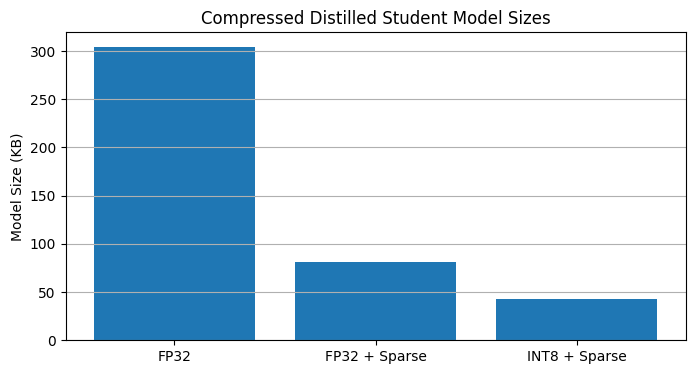

In [38]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


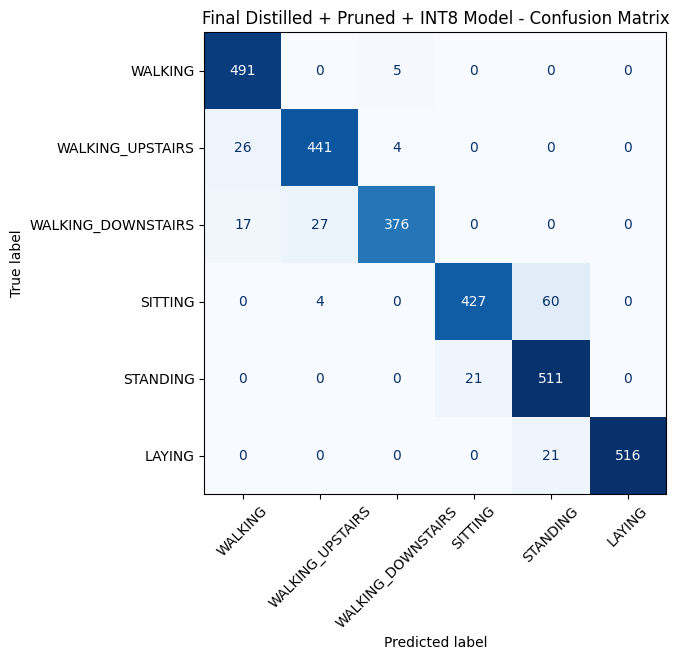

In [39]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
2. Did **knowledge distillation** help the smaller model retain performance?
3. What happened to the model size after **pruning** and after **INT8 quantization**?
4. Which model would you choose for **Arduino deployment**, and why?
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?


1. The distilled student achieved higher accuracy and better generalization than the baseline student
2. Yes. By training on the teacher's "soft targets," the student received richer gradient signals. This allowed it to capture complex inter-class relationships.
3. Pruning zeroed out low-magnitude weights, making the model highly compressible.
INT8 Quantization strictly reduced the physical memory footprint of the remaining non-zero weights by an additional factor of 4x (converting 32-bit floating-point numbers to 8-bit integers).
4. I would choose the fully optimized Sparse INT8 Distilled Student.This model is the only one guaranteed to fit within a few hundred kilobytes while retaining acceptable task accuracy.
5. It perfectly balances hardware constraints with predictive power. Sparsity reduces the total number of required operations, while INT8 math executes significantly faster and consumes far less power on embedded processors

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
